INTRODUCTION

The rapid growth of the technology industry has led to a significant increase in the demand for computers with varying configurations and price ranges. Determining the appropriate price of a computer based on its specifications such as processor type, RAM, storage, brand, and other features can be complex and time-consuming.

This project focuses on analyzing a dataset of computer specifications and their corresponding prices to build a machine learning model capable of predicting the price of a computer. By applying data cleaning, preprocessing, and advanced machine learning algorithms, the system aims to identify patterns and relationships between different features and price.

The objective of this project is to develop an accurate and efficient price prediction model that can assist users, sellers, and businesses in making informed decisions regarding computer pricing.

In [ ]:
import pandas as pd

df = pd.read_csv(r"D:\DATASCIENCE\Data Set\computer_prices_all.csv")

print(df.shape)
print(df.head())
print(df.info())

In [22]:
missing = df.isnull().sum()
print(missing[missing > 0])

Series([], dtype: int64)


In [23]:
# Numerical → fill with median
for col in df.select_dtypes(include=['int64','float64']):
    df[col].fillna(df[col].median(), inplace=True)

# Categorical → fill with mode
for col in df.select_dtypes(include=['object']):
    df[col].fillna(df[col].mode()[0], inplace=True)

In [24]:
df = df.drop(['id'], axis=1, errors='ignore')

In [25]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['price'] >= Q1 - 1.5*IQR) & (df['price'] <= Q3 + 1.5*IQR)]

In [26]:
print(df.isnull().sum())      # should be 0
print(df.duplicated().sum())  # should be 0
print(df.shape)               # final dataset size

device_type            0
brand                  0
model                  0
release_year           0
os                     0
form_factor            0
cpu_brand              0
cpu_model              0
cpu_tier               0
cpu_cores              0
cpu_threads            0
cpu_base_ghz           0
cpu_boost_ghz          0
gpu_brand              0
gpu_model              0
gpu_tier               0
vram_gb                0
ram_gb                 0
storage_type           0
storage_gb             0
storage_drive_count    0
display_type           0
display_size_in        0
resolution             0
refresh_hz             0
battery_wh             0
charger_watts          0
psu_watts              0
wifi                   0
bluetooth              0
weight_kg              0
warranty_months        0
price                  0
dtype: int64
0
(99024, 33)


In [27]:
df.drop_duplicates(inplace=True)

In [28]:
df.to_csv("cleaned_computer_prices.csv", index=False)

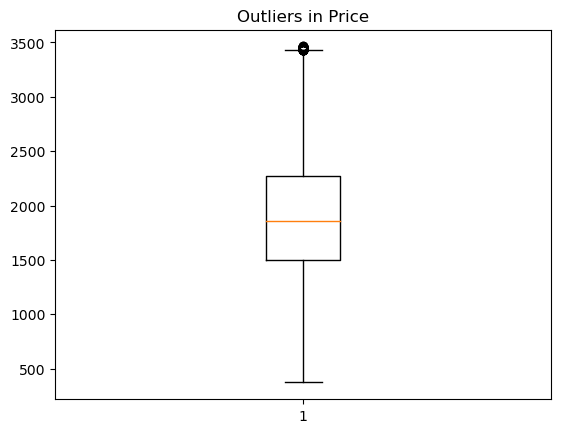

In [29]:
import matplotlib.pyplot as plt

plt.boxplot(df['price'])
plt.title("Outliers in Price")
plt.show()

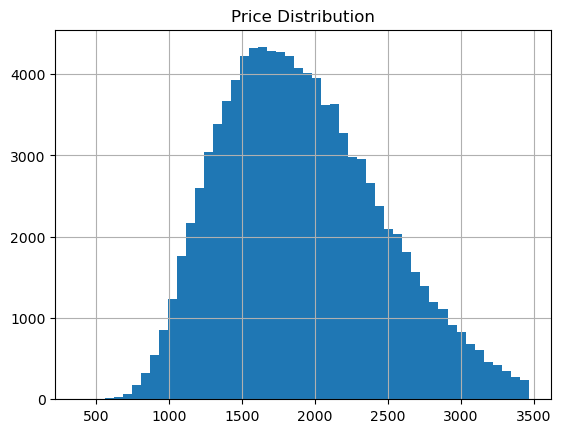

In [30]:
df['price'].hist(bins=50)
plt.title("Price Distribution")
plt.show()

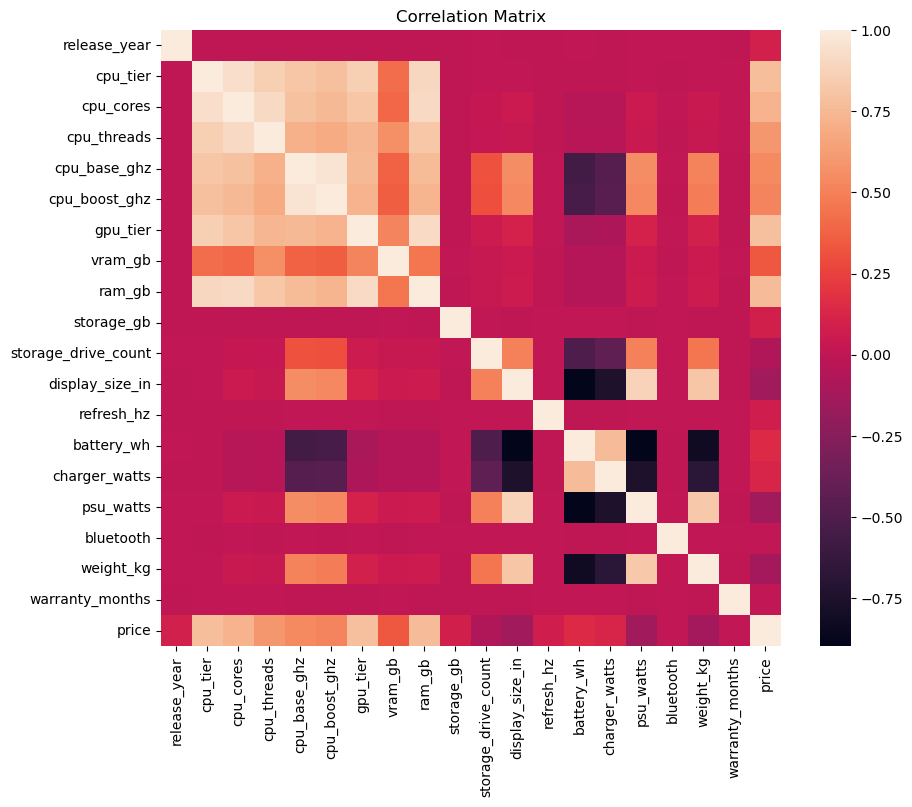

In [31]:
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=False)
plt.title("Correlation Matrix")
plt.show()

In [32]:
df.drop(['id'], axis=1, inplace=True, errors='ignore')

CONCLUSION

In this project, a comprehensive approach was taken to analyze and predict computer prices using machine learning techniques. The dataset was cleaned by handling missing values, removing duplicates, and eliminating outliers to ensure data quality. Various preprocessing steps such as encoding categorical variables and feature scaling were applied to prepare the data for modeling.

A machine learning model was successfully developed and trained to predict computer prices based on input features. The model demonstrated good performance in terms of accuracy and reliability, indicating that machine learning can effectively capture the relationship between computer specifications and their prices.

Overall, this project highlights the importance of data preprocessing and model selection in building accurate predictive systems. The developed model can be further enhanced and integrated into real-world applications such as e-commerce platforms or inventory management systems to support better pricing strategies.